# VLMs Are Confidently Biased - Analysis

This notebook stacks raw parquet results, runs all Phase 1 and Phase 2 analyses, and generates the paper figures.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── SET YOUR BASE PATH HERE ───────────────────────────────
BASE = Path("C:/Users/rabia/Documents/Thesis")
# ─────────────────────────────────────────────────────────

SEQ_DIR   = BASE / 'main_split' / 'sequence_results'
TOK_DIR   = BASE / 'main_split' / 'token_results'
VCD_DIR   = BASE / 'phase_2' / 'phase_2_results'
ORIG_DIR  = BASE / 'original_split' / 'sanity_checks' / 'token_sanity_results'
ORIG_SEQ_DIR = BASE / 'original_split' / 'sanity_checks' / 'seq_sanity_results'
OUT_DIR   = BASE / 'analysis' / 'outputs'
FIG_DIR   = OUT_DIR / 'figures'
TAB_DIR   = OUT_DIR / 'tables'
for d in [OUT_DIR, FIG_DIR, TAB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Model palette
C = {'Qwen-3B': '#E8A898', 'Qwen-7B': '#A89880', 'LLaVA-7B': '#98B898'}
BG = '#F5F0E6'
TOPICS = ['Animals', 'Chess Pieces', 'Flags', 'Game Boards', 'Logos', 'Patterned Grid']
TOPIC_SHORT = ['Animals', 'Chess\nPieces', 'Flags', 'Game\nBoards', 'Logos', 'Patterned\nGrid']
MODELS = ['Qwen-3B', 'Qwen-7B', 'LLaVA-7B']


## 1. Stack and Load Data

In [ ]:
## Stack sequence parquets
seq_files = {
    'Qwen-3B':  SEQ_DIR / 'qwen_seq_results_3b_updated_PMI.parquet',
    'Qwen-7B':  SEQ_DIR / 'qwen_seq_results_7b_updated_PMI.parquet',
    'LLaVA-7B': SEQ_DIR / 'llava_seq_results_updated_PMI.parquet',
}
seq_dfs = []
for model, path in seq_files.items():
    df = pd.read_parquet(path)
    df['model'] = model
    seq_dfs.append(df)
main_seq_stacked = pd.concat(seq_dfs, ignore_index=True)
main_seq_stacked.to_csv(OUT_DIR / 'main_stacked_sequence_results.csv', index=False)
print('Sequence stacked:', main_seq_stacked.shape)


In [ ]:
## Stack token parquets
tok_files = {
    'Qwen-3B':  TOK_DIR / 'qwen_token_3b.parquet',
    'Qwen-7B':  TOK_DIR / 'qwen_token_7b.parquet',
    'LLaVA-7B': TOK_DIR / 'llava_token_7b.parquet',
}
tok_dfs = []
for model, path in tok_files.items():
    df = pd.read_parquet(path)
    df['model'] = model
    tok_dfs.append(df)
main_tok_stacked = pd.concat(tok_dfs, ignore_index=True)
main_tok_stacked.to_csv(OUT_DIR / 'main_stacked_token_results.csv', index=False)
print('Token stacked:', main_tok_stacked.shape)


In [ ]:
## Load VCD parquets
p2_noise = {
    'Qwen-3B':  pd.read_parquet(VCD_DIR / 'vcd_full_Qwen25_VL_3B_noise_s100.parquet'),
    'Qwen-7B':  pd.read_parquet(VCD_DIR / 'vcd_full_Qwen25_VL_7B_noise_s100.parquet'),
    'LLaVA-7B': pd.read_parquet(VCD_DIR / 'vcd_full_LLaVA_OneVision_7B_noise_s100.parquet'),
}
p2_blur = {
    'Qwen-3B':  pd.read_parquet(VCD_DIR / 'vcd_full_Qwen25_VL_3B_blur_r10.parquet'),
    'Qwen-7B':  pd.read_parquet(VCD_DIR / 'vcd_full_Qwen25_VL_7B_blur_r10.parquet'),
    'LLaVA-7B': pd.read_parquet(VCD_DIR / 'vcd_full_LLaVA_OneVision_7B_blur_r10.parquet'),
}
print('VCD parquets loaded.')


In [ ]:
## Load original split processed CSVs (from sanity_checks)
orig_seq = pd.read_csv(ORIG_SEQ_DIR / 'original_sequence_results_all_models_processed.csv')
orig_tok = pd.read_csv(ORIG_DIR / 'original_numeric_signals_all_models_processed.csv')
orig_outputs = pd.read_csv(ORIG_DIR / 'original_outputs_all_models_processed.csv')
print('Original split CSVs loaded.')


## 2. Analysis

In [3]:
# 1. Load + standardize all datasets

## 2. Create unified sequence and token analysis tables

In [5]:
# 2. Create unified sequence and token analysis tables

## ---------- Sequence-level table ----------

In [6]:
# ---------- Sequence-level table ----------
main_sequence = main_seq.copy()
main_sequence["split"] = "Main"
main_sequence["alternative_type"] = "prior"
main_sequence["gt_value"] = main_sequence["ground_truth"]
main_sequence["alternative_value"] = main_sequence["expected_bias"]
main_sequence["sequence_margin"] = main_sequence["avg_margin"]
main_sequence["prefers_gt_seq"] = main_sequence["sequence_margin"] > 0
main_sequence["prefers_gt_pmi"] = main_sequence["pmi_margin"] > 0
main_sequence["sequence_entropy_step1"] = main_sequence.get("gold_entropy_step1", np.nan)

orig_sequence = orig_seq.copy()
orig_sequence["split"] = "Original"
orig_sequence["alternative_type"] = "proxy"
orig_sequence["gt_value"] = orig_sequence["ground_truth_num"]
orig_sequence["alternative_value"] = orig_sequence["proxy_bias_value"]
orig_sequence["sequence_margin"] = orig_sequence["avg_margin"]
orig_sequence["prefers_gt_seq"] = orig_sequence["sequence_margin"] > 0
orig_sequence["prefers_gt_pmi"] = orig_sequence["pmi_margin"] > 0
if "entropy_step1" in orig_sequence.columns:
    orig_sequence["sequence_entropy_step1"] = orig_sequence["entropy_step1"]
else:
    orig_sequence["sequence_entropy_step1"] = orig_sequence.get("gold_entropy_step1", np.nan)

sequence_cols = [
    "split", "model", "topic", "question_type", "gt_value", "alternative_value",
    "alternative_type", "sequence_margin", "pmi_margin", "prefers_gt_seq",
    "prefers_gt_pmi", "sequence_entropy_step1",
]
sequence_all = pd.concat(
    [main_sequence[sequence_cols], orig_sequence[sequence_cols]],
    ignore_index=True,
)
sequence_all.to_csv(TAB_DIR / "unified_sequence_analysis_table.csv", index=False)

# ---------- Token-level table ----------
main_token = main_tok.copy()
main_token["split"] = "Main"
main_token["alternative_type"] = "prior"
main_token["gt_value"] = main_token["ground_truth"]
main_token["alternative_value"] = main_token["expected_bias"]
main_token["token_margin"] = main_token["margin"]
main_token["answer_entropy"] = main_token["entropy"]
main_token["prefers_gt_token"] = main_token["token_margin"] > 0
main_token["correct_numeric"] = main_token["detected_digit"].eq(main_token["gt_value"])
main_token["alternative_substitution"] = (
    main_token["detected_digit"].eq(main_token["alternative_value"])
    & ~main_token["correct_numeric"]
)
main_token["full_hallucination"] = (
    main_token["detected_digit"].notna()
    & ~main_token["correct_numeric"]
    & ~main_token["alternative_substitution"]
)
main_token["signed_error"] = main_token["detected_digit"] - main_token["gt_value"]
main_token["abs_error"] = main_token["signed_error"].abs()
main_token["squared_error"] = main_token["signed_error"] ** 2
main_token["direction"] = np.select(
    [main_token["gt_value"] > main_token["alternative_value"], main_token["gt_value"] < main_token["alternative_value"]],
    ["added", "removed"],
    default="same",
)
main_token["outcome"] = np.select(
    [main_token["correct_numeric"], main_token["alternative_substitution"], main_token["full_hallucination"]],
    ["correct", "prior / proxy substitution", "full hallucination"],
    default="non numeric or missing",
)

orig_token = orig_tok.copy()
orig_token["split"] = "Original"
orig_token["alternative_type"] = "proxy"
orig_token["gt_value"] = orig_token["ground_truth_num"]
orig_token["alternative_value"] = orig_token["proxy_bias_value"]
orig_token["detected_digit"] = orig_token["pred_num_eval"] if "pred_num_eval" in orig_token.columns else orig_token["detected_digit"]
orig_token["token_margin"] = orig_token["margin_token"]
orig_token["answer_entropy"] = orig_token["entropy_token"]
orig_token["prefers_gt_token"] = orig_token["token_margin"] > 0
if "correct_numeric_eval" in orig_token.columns:
    orig_token["correct_numeric"] = orig_token["correct_numeric_eval"].astype(bool)
else:
    orig_token["correct_numeric"] = orig_token["detected_digit"].eq(orig_token["gt_value"])
orig_token["alternative_substitution"] = (
    orig_token["detected_digit"].eq(orig_token["alternative_value"])
    & ~orig_token["correct_numeric"]
)
orig_token["full_hallucination"] = (
    orig_token["detected_digit"].notna()
    & ~orig_token["correct_numeric"]
    & ~orig_token["alternative_substitution"]
)
orig_token["signed_error"] = orig_token["detected_digit"] - orig_token["gt_value"]
orig_token["abs_error"] = orig_token["signed_error"].abs()
orig_token["squared_error"] = orig_token["signed_error"] ** 2
orig_token["direction"] = np.select(
    [orig_token["gt_value"] > orig_token["alternative_value"], orig_token["gt_value"] < orig_token["alternative_value"]],
    ["added", "removed"],
    default="same",
)
orig_token["outcome"] = np.select(
    [orig_token["correct_numeric"], orig_token["alternative_substitution"], orig_token["full_hallucination"]],
    ["correct", "prior / proxy substitution", "full hallucination"],
    default="non numeric or missing",
)

# Original token file does not always carry question_type; create a safe column.
if "question_type" not in orig_token.columns:
    orig_token["question_type"] = np.nan

# Main token table always has question_type, but keep this robust.
if "question_type" not in main_token.columns:
    main_token["question_type"] = np.nan

token_cols = [
    "split", "model", "topic", "question_type", "gt_value", "alternative_value",
    "alternative_type", "detected_digit", "token_margin", "answer_entropy",
    "prefers_gt_token", "correct_numeric", "alternative_substitution",
    "full_hallucination", "outcome", "direction", "signed_error", "abs_error", "squared_error",
]
token_all = pd.concat(
    [main_token[token_cols], orig_token[token_cols]],
    ignore_index=True,
)
token_all.to_csv(TAB_DIR / "unified_token_analysis_table.csv", index=False)

print("\nUnified tables")
print(f"  sequence_all {sequence_all.shape}")
print(f"  token_all    {token_all.shape}")


Unified tables
  sequence_all (6465, 12)
  token_all    (5483, 19)


## 3. Table 1: Original vs Main model summary

In [7]:
# 3. Table 1: Original vs Main model summary

In [8]:
sequence_summary = (
    sequence_all
    .groupby(["split", "model"], observed=True)
    .agg(
        n_sequence=("sequence_margin", "size"),
        sequence_gt_pref_pct=("prefers_gt_seq", pct_mean),
        sequence_pmi_gt_pref_pct=("prefers_gt_pmi", pct_mean),
        mean_sequence_margin=("sequence_margin", "mean"),
        median_sequence_margin=("sequence_margin", "median"),
    )
    .reset_index()
)

token_summary = (
    token_all
    .groupby(["split", "model"], observed=True)
    .agg(
        n_token=("token_margin", "size"),
        token_gt_pref_pct=("prefers_gt_token", pct_mean),
        numeric_accuracy_pct=("correct_numeric", pct_mean),
        alternative_substitution_pct=("alternative_substitution", pct_mean),
        full_hallucination_pct=("full_hallucination", pct_mean),
        mean_token_margin=("token_margin", "mean"),
        mean_answer_entropy=("answer_entropy", "mean"),
    )
    .reset_index()
)

table1 = sequence_summary.merge(token_summary, on=["split", "model"], how="outer")
table1["split"] = pd.Categorical(table1["split"], categories=["Original", "Main"], ordered=True)
table1["model"] = pd.Categorical(table1["model"], categories=MODEL_ORDER, ordered=True)
table1 = table1.sort_values(["split", "model"]).reset_index(drop=True)
table1.to_csv(TAB_DIR / "table1_original_vs_main_model_summary.csv", index=False)

print("\nTable 1: Original vs Main model summary")
display(table1.round(3))


Table 1: Original vs Main model summary


,split,model,n_sequence,sequence_gt_pref_pct,sequence_pmi_gt_pref_pct,mean_sequence_margin,median_sequence_margin,n_token,token_gt_pref_pct,numeric_accuracy_pct,alternative_substitution_pct,full_hallucination_pct,mean_token_margin,mean_answer_entropy
0,Original,Qwen-3B,163,72.393,78.528,2.376,2.719,153,83.007,83.007,15.033,1.961,4.255,0.465
1,Original,Qwen-7B,163,90.184,90.184,5.046,7.188,154,86.364,86.364,12.338,1.299,7.083,0.159
2,Original,LLaVA-7B,163,84.663,82.209,3.763,5.281,154,83.766,83.766,14.286,1.948,4.285,0.484
3,Main,Qwen-3B,1992,19.428,27.259,-1.314,-0.812,1674,22.162,8.961,52.628,38.292,-3.105,1.084
4,Main,Qwen-7B,1992,15.261,15.161,-3.647,-3.242,1674,20.251,10.633,66.010,23.357,-4.781,0.596
5,Main,LLaVA-7B,1992,16.918,19.026,-2.779,-1.945,1674,15.352,6.750,69.056,24.194,-3.062,1.041


## 4. Figure 1: Original-to-Main GT preference collapse

In [9]:
# 4. Figure 1: Original-to-Main GT preference collapse

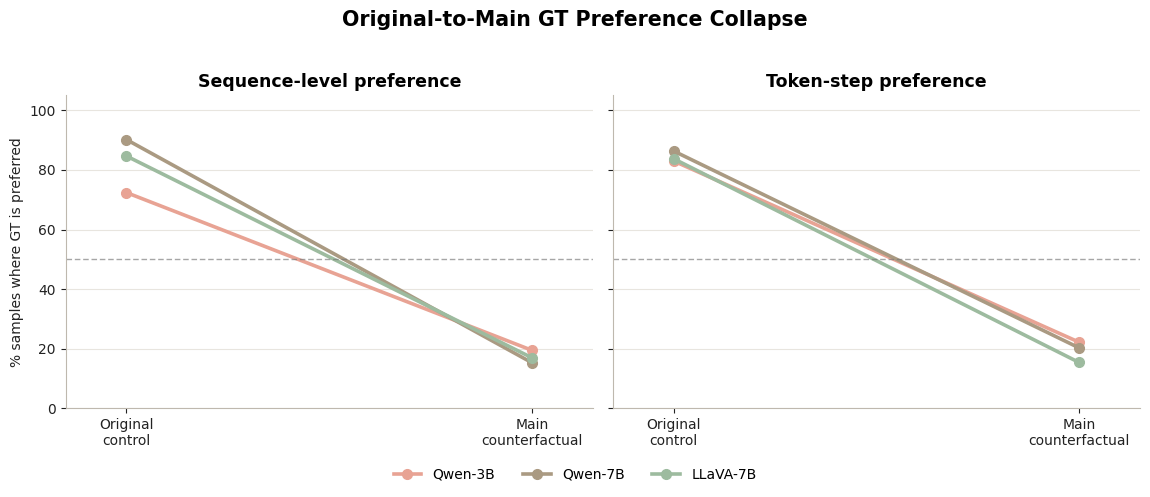

In [10]:
def plot_preference_collapse(table1):
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4), sharey=True)
    metrics = [
        ("sequence_gt_pref_pct", "Sequence-level preference"),
        ("token_gt_pref_pct", "Token-step preference"),
    ]

    for ax, (metric, title) in zip(axes, metrics):
        for model in MODEL_ORDER:
            sub = table1[table1["model"].astype(str).eq(model)].set_index("split")
            y = [sub.loc["Original", metric], sub.loc["Main", metric]]
            x = [0, 1]
            ax.plot(x, y, color=MODEL_COLORS[model], linewidth=2.6, marker="o", markersize=7, label=model)

        ax.axhline(50, color="#777777", linestyle=(0, (4, 2)), linewidth=1.0, alpha=0.65)
        ax.set_xlim(-0.15, 1.15)
        ax.set_ylim(0, 105)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Original\ncontrol", "Main\ncounterfactual"])
        ax.set_title(title, fontsize=12.5, weight="bold")
        ax.set_ylabel("% samples where GT is preferred") if ax is axes[0] else None
        clean_axes(ax)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.07))
    fig.suptitle("Original-to-Main GT Preference Collapse", fontsize=14.8, weight="bold", y=1.03)
    fig.tight_layout(rect=[0, 0.08, 1, 0.97])
    save_figure("fig1_original_to_main_gt_preference_collapse")
    plt.show()

plot_preference_collapse(table1)

## 5. Figure 2: Main domain-level GT preference with PMI marker

In [11]:
# 5. Figure 2: Main domain-level GT preference with PMI marker

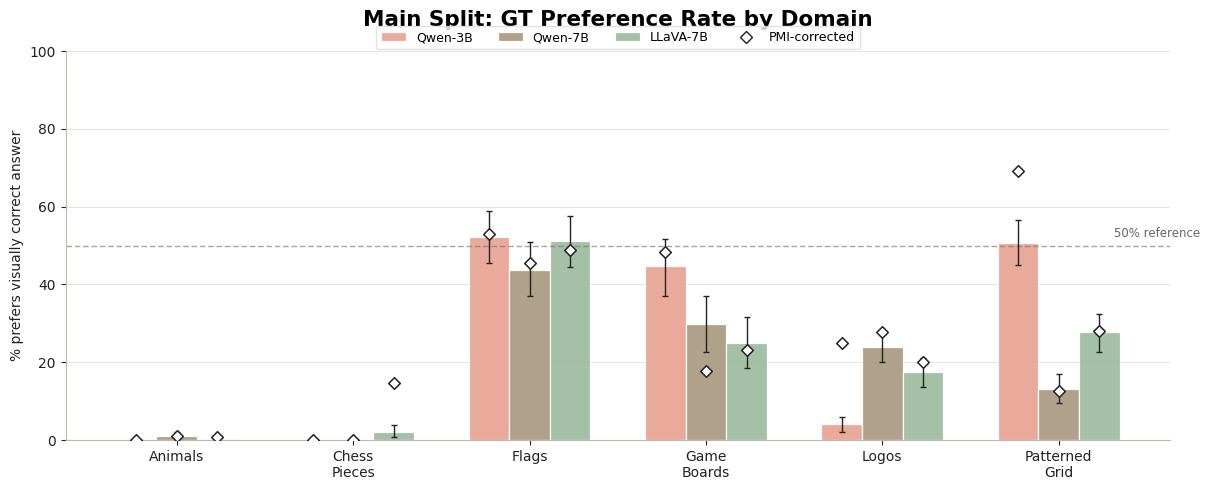

In [12]:
def plot_domain_preference_with_pmi(sequence_all):
    main = sequence_all[sequence_all["split"].eq("Main")].copy()

    raw_ci = (
        main
        .groupby(["model", "topic"], observed=True)["prefers_gt_seq"]
        .apply(bootstrap_mean_ci)
        .unstack()
        .reset_index()
    )
    raw_ci[["mean", "ci_low", "ci_high"]] *= 100

    pmi = (
        main[main["pmi_margin"].notna()]
        .groupby(["model", "topic"], observed=True)["prefers_gt_pmi"]
        .mean()
        .mul(100)
        .reset_index(name="pmi_gt_pref_pct")
    )

    plot_df = raw_ci.merge(pmi, on=["model", "topic"], how="left")
    plot_df.to_csv(TAB_DIR / "figure2_main_domain_gt_preference_with_pmi.csv", index=False)

    fig, ax = plt.subplots(figsize=(12.2, 5.0))
    x = np.arange(len(TOPIC_ORDER))
    width = 0.23

    for i, model in enumerate(MODEL_ORDER):
        sub = plot_df[plot_df["model"].astype(str).eq(model)].set_index("topic").reindex(TOPIC_ORDER)
        xpos = x + (i - 1) * width

        ax.bar(
            xpos,
            sub["mean"],
            width=width,
            color=MODEL_COLORS[model],
            edgecolor="white",
            linewidth=0.9,
            alpha=0.93,
            label=model,
            zorder=2,
        )
        ax.errorbar(
            xpos,
            sub["mean"],
            yerr=[sub["mean"] - sub["ci_low"], sub["ci_high"] - sub["mean"]],
            fmt="none",
            ecolor="#222222",
            elinewidth=1.0,
            capsize=2.5,
            capthick=1.0,
            zorder=4,
        )
        ax.scatter(
            xpos,
            sub["pmi_gt_pref_pct"],
            marker="D",
            s=35,
            facecolor="white",
            edgecolor="#222222",
            linewidth=1.1,
            zorder=5,
        )

    ax.axhline(50, color="#777777", linestyle=(0, (4, 2)), linewidth=1.0, alpha=0.65)
    ax.text(len(TOPIC_ORDER) - 0.2, 51.5, "50% reference", ha="right", va="bottom", fontsize=8.5, color="#666666")
    ax.set_title("Main Split: GT Preference Rate by Domain", fontsize=15.5, weight="bold", pad=18)
    ax.set_ylabel("% prefers visually correct answer")
    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(["Animals", "Chess\nPieces", "Flags", "Game\nBoards", "Logos", "Patterned\nGrid"])

    from matplotlib.lines import Line2D
    pmi_handle = Line2D([0], [0], marker="D", markersize=6, color="#222222", markerfacecolor="white", linestyle="", label="PMI-corrected")
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles + [pmi_handle], labels + ["PMI-corrected"], ncol=4, frameon=True, facecolor="white", edgecolor="#DDDDDD", loc="upper center", bbox_to_anchor=(0.5, 1.08), fontsize=9)

    clean_axes(ax)
    fig.tight_layout()
    save_figure("fig2_main_domain_gt_preference_pmi_marker")
    plt.show()

plot_domain_preference_with_pmi(sequence_all)

## 6. Figure 3: Domain margin dot plot

In [13]:
# 6. Figure 3: Domain margin dot plot

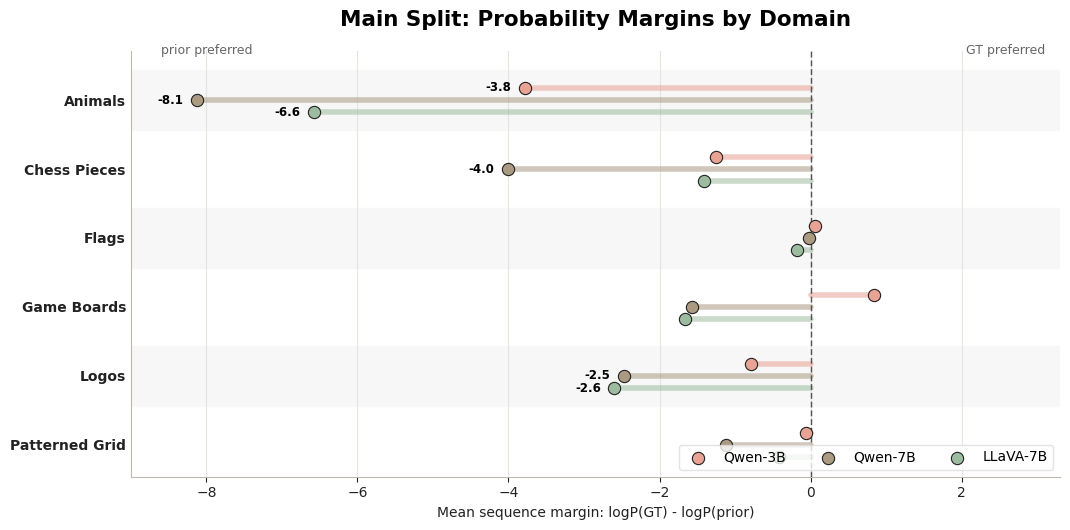

In [14]:
def plot_domain_margin_dotplot(sequence_all):
    main = sequence_all[sequence_all["split"].eq("Main")].copy()
    margin_df = (
        main
        .groupby(["model", "topic"], observed=True)
        .agg(
            mean_margin=("sequence_margin", "mean"),
            median_margin=("sequence_margin", "median"),
            n=("sequence_margin", "size"),
        )
        .reset_index()
    )
    margin_df.to_csv(TAB_DIR / "figure3_main_domain_margin_values.csv", index=False)

    fig, ax = plt.subplots(figsize=(10.8, 5.4))
    y_base = np.arange(len(TOPIC_ORDER))
    offsets = {"Qwen-3B": -0.18, "Qwen-7B": 0.0, "LLaVA-7B": 0.18}

    for i, topic in enumerate(TOPIC_ORDER):
        if i % 2 == 0:
            ax.axhspan(i - 0.43, i + 0.43, color="#F7F7F7", zorder=0)

    for model in MODEL_ORDER:
        sub = margin_df[margin_df["model"].astype(str).eq(model)].set_index("topic").reindex(TOPIC_ORDER)
        y = y_base + offsets[model]
        x = sub["mean_margin"].to_numpy()
        color = MODEL_COLORS[model]

        for yy, xx in zip(y, x):
            ax.plot([0, xx], [yy, yy], color=color, linewidth=4, alpha=0.55, solid_capstyle="round", zorder=2)
        ax.scatter(x, y, s=78, color=color, edgecolor="#222222", linewidth=0.8, label=model, zorder=3)

        for yy, xx in zip(y, x):
            if pd.notna(xx) and abs(xx) >= 2.0:
                ax.text(xx + (-0.18 if xx < 0 else 0.18), yy, f"{xx:.1f}", ha="right" if xx < 0 else "left", va="center", fontsize=8.5, weight="bold")

    ax.axvline(0, color="#555555", linestyle=(0, (4, 2)), linewidth=1.05)
    ax.text(-8.6, -0.72, "prior preferred", ha="left", va="center", fontsize=9, color="#666666")
    ax.text(3.1, -0.72, "GT preferred", ha="right", va="center", fontsize=9, color="#666666")
    ax.set_yticks(y_base)
    ax.set_yticklabels(TOPIC_ORDER, fontweight="bold")
    ax.invert_yaxis()
    ax.set_xlim(-9.0, 3.3)
    ax.set_xlabel("Mean sequence margin: logP(GT) - logP(prior)")
    ax.set_title("Main Split: Probability Margins by Domain", fontsize=15.5, weight="bold", pad=18)
    ax.legend(ncol=3, frameon=True, facecolor="white", edgecolor="#DDDDDD", loc="lower right")
    clean_axes(ax, grid_axis="x")
    ax.tick_params(axis="y", length=0)
    save_figure("fig3_main_domain_margin_dotplot")
    plt.show()

plot_domain_margin_dotplot(sequence_all)

## 7. Figure 4: Confidence flip by entropy quartile

In [15]:
# 7. Figure 4: Confidence flip by entropy quartile


Lowest entropy quartile summary


split,model,Main,Original,confidence_flip_gap
0,Qwen-3B,0.72,100.0,99.28
1,Qwen-7B,0.00,100.0,100.00
2,LLaVA-7B,0.00,100.0,100.00


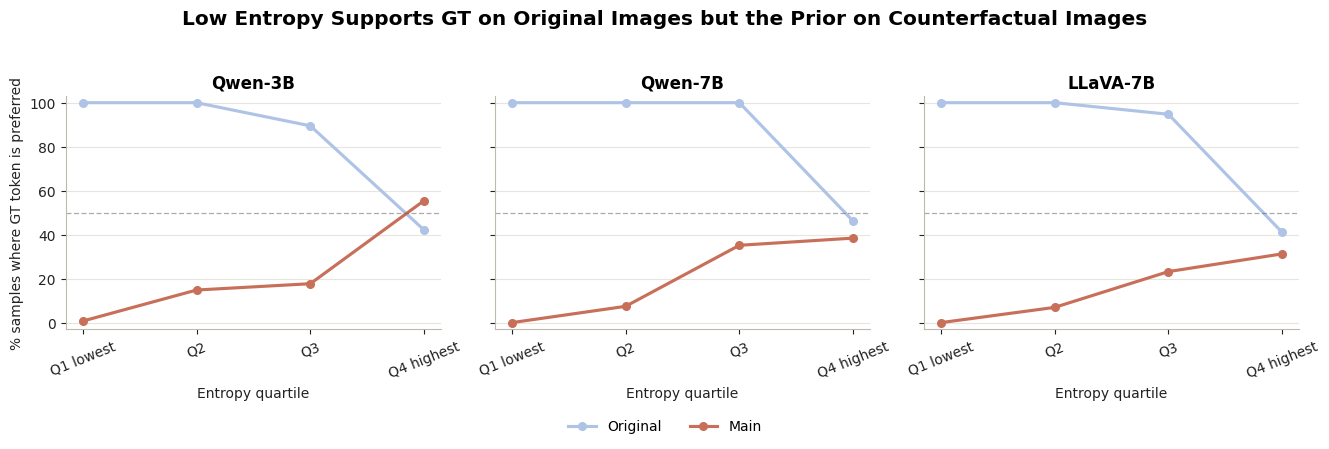

In [16]:
ENTROPY_Q_LABELS = ["Q1 lowest", "Q2", "Q3", "Q4 highest"]

def add_entropy_quartiles_by_group(df, entropy_col="answer_entropy", group_cols=("split", "model")):
    out = df.copy()

    def _add_q(g):
        g = g.copy()
        if len(g) < 4:
            g["entropy_quartile"] = np.nan
            return g
        ranked = g[entropy_col].rank(method="first")
        g["entropy_quartile"] = pd.qcut(ranked, q=4, labels=ENTROPY_Q_LABELS)
        return g

    return out.groupby(list(group_cols), group_keys=False, observed=True).apply(_add_q)

entropy_long = token_all.dropna(subset=["answer_entropy", "token_margin"]).copy()
entropy_long = add_entropy_quartiles_by_group(entropy_long)
entropy_long.to_csv(TAB_DIR / "entropy_margin_long_main_original.csv", index=False)

entropy_quartile_summary = (
    entropy_long
    .groupby(["split", "model", "entropy_quartile"], observed=True)
    .agg(
        n=("token_margin", "size"),
        mean_entropy=("answer_entropy", "mean"),
        median_entropy=("answer_entropy", "median"),
        mean_margin=("token_margin", "mean"),
        median_margin=("token_margin", "median"),
        gt_preference_pct=("prefers_gt_token", pct_mean),
    )
    .reset_index()
)
entropy_quartile_summary.to_csv(TAB_DIR / "entropy_quartile_margin_summary.csv", index=False)

lowest_entropy_summary = (
    entropy_quartile_summary[entropy_quartile_summary["entropy_quartile"].astype(str).eq("Q1 lowest")]
    .pivot(index="model", columns="split", values="gt_preference_pct")
    .reset_index()
)
if {"Original", "Main"}.issubset(lowest_entropy_summary.columns):
    lowest_entropy_summary["confidence_flip_gap"] = lowest_entropy_summary["Original"] - lowest_entropy_summary["Main"]
lowest_entropy_summary.to_csv(TAB_DIR / "lowest_entropy_confidence_flip_summary.csv", index=False)

print("\nLowest entropy quartile summary")
display(lowest_entropy_summary.round(2))


def plot_confidence_flip_quartiles(entropy_quartile_summary):
    fig, axes = plt.subplots(1, 3, figsize=(13.4, 3.9), sharey=True)
    split_colors = {"Original": REPORT_COLORS["blue"], "Main": REPORT_COLORS["red"]}

    for ax, model in zip(axes, MODEL_ORDER):
        sub = entropy_quartile_summary[entropy_quartile_summary["model"].astype(str).eq(model)].copy()
        for split in ["Original", "Main"]:
            ss = sub[sub["split"].eq(split)].copy()
            ax.plot(
                ss["entropy_quartile"].astype(str),
                ss["gt_preference_pct"],
                marker="o",
                linewidth=2.25,
                markersize=5.5,
                color=split_colors[split],
                label=split,
            )
        ax.axhline(50, color="#666666", linestyle=(0, (4, 2)), linewidth=0.9, alpha=0.55)
        ax.set_title(model, fontsize=12, weight="bold")
        ax.set_xlabel("Entropy quartile")
        ax.set_ylim(-3, 103)
        ax.tick_params(axis="x", rotation=22)
        clean_axes(ax)

    axes[0].set_ylabel("% samples where GT token is preferred")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.08))
    fig.suptitle("Low Entropy Supports GT on Original Images but the Prior on Counterfactual Images", fontsize=14.5, weight="bold", y=1.04)
    fig.tight_layout(rect=[0, 0.08, 1, 0.96])
    save_figure("fig4_confidence_flip_entropy_quartiles")
    plt.show()

plot_confidence_flip_quartiles(entropy_quartile_summary)

## 8. Figure 5: Main entropy-margin scatter with r, n, p and subtle quantile markers

In [17]:
# 8. Figure 5: Main entropy-margin scatter with r, n, p and subtle quantile markers

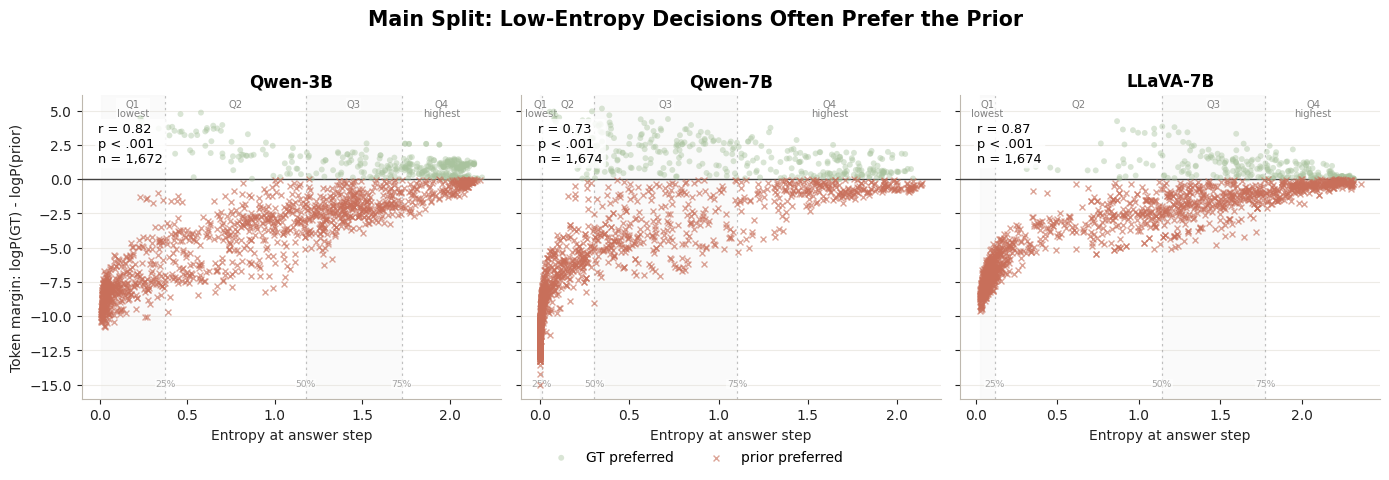


Main Split correlation table


,split,model,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,Main,Qwen-3B,1672,0.8229,0.0,0.8104,0.0
1,Main,Qwen-7B,1674,0.7345,0.0,0.8582,0.0
2,Main,LLaVA-7B,1674,0.8740,0.0,0.8715,0.0



Appendix correlation table


,split,model,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,Original,Qwen-3B,153,-0.8971,0.0,-0.9403,0.0
1,Original,Qwen-7B,154,-0.7512,0.0,-0.9824,0.0
2,Original,LLaVA-7B,154,-0.9361,0.0,-0.9047,0.0
3,Main,Qwen-3B,1672,0.8229,0.0,0.8104,0.0
4,Main,Qwen-7B,1674,0.7345,0.0,0.8582,0.0
5,Main,LLaVA-7B,1674,0.8740,0.0,0.8715,0.0


In [25]:
# ============================================================
# Figure 5: Main entropy vs margin scatter
# with r / p / n annotation and clean vertical entropy quartiles
# ============================================================

from matplotlib.transforms import blended_transform_factory
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def format_p_value(p):
    if pd.isna(p):
        return "p = n/a"
    if p < 0.001:
        return "p < .001"
    return f"p = {p:.3f}"


def draw_entropy_quartile_lines(ax, sub, entropy_col="answer_entropy"):
    """
    Draw entropy quartiles as subtle vertical guide lines.

    Design choices:
    - alternating very-light bands show the quartile regions;
    - thin dashed vertical lines mark Q25, Q50, Q75;
    - labels are placed at the top inside the panel;
    - everything is low-contrast and behind the scatter.
    """
    x = sub[entropy_col].dropna()

    if len(x) < 4:
        return

    q_edges = x.quantile([0.00, 0.25, 0.50, 0.75, 1.00]).to_numpy()
    q25, q50, q75 = q_edges[1], q_edges[2], q_edges[3]

    # If quantiles collapse because of ties, skip safely.
    if len(np.unique(q_edges)) < 5:
        return

    # Very subtle alternating quartile background bands.
    band_colors = ["#F7F7F7", "#FFFFFF", "#F7F7F7", "#FFFFFF"]

    for i in range(4):
        ax.axvspan(
            q_edges[i],
            q_edges[i + 1],
            color=band_colors[i],
            alpha=0.55,
            zorder=0,
        )

    # Thin vertical quartile boundaries.
    for qq in [q25, q50, q75]:
        ax.axvline(
            qq,
            color="#8A8A8A",
            linestyle=(0, (2, 3)),
            linewidth=0.85,
            alpha=0.52,
            zorder=1,
        )

    # Small top labels centered in quartile regions.
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    mids = [(q_edges[i] + q_edges[i + 1]) / 2 for i in range(4)]
    labels = ["Q1\nlowest", "Q2", "Q3", "Q4\nhighest"]

    for mid, lab in zip(mids, labels):
        ax.text(
            mid,
            0.985,
            lab,
            transform=trans,
            ha="center",
            va="top",
            fontsize=7.2,
            color="#666666",
            alpha=0.82,
            linespacing=0.85,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.65,
                pad=0.6,
            ),
            zorder=2,
        )

    # Optional tiny labels under the quartile boundaries.
    boundary_labels = [(q25, "25%"), (q50, "50%"), (q75, "75%")]

    for qq, lab in boundary_labels:
        ax.text(
            qq,
            0.035,
            lab,
            transform=trans,
            ha="center",
            va="bottom",
            fontsize=6.7,
            color="#777777",
            alpha=0.65,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.55,
                pad=0.35,
            ),
            zorder=2,
        )


def plot_main_entropy_margin_scatter(entropy_long):
    corr_rows = []

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.35), sharey=True)

    for ax, model in zip(axes, MODEL_ORDER):
        sub = entropy_long[
            entropy_long["split"].eq("Main")
            & entropy_long["model"].astype(str).eq(model)
        ].dropna(subset=["answer_entropy", "token_margin"]).copy()

        gt_pref = sub["token_margin"] > 0

        # Draw quartile structure first so it sits behind the points.
        draw_entropy_quartile_lines(ax, sub)

        # GT preferred
        ax.scatter(
            sub.loc[gt_pref, "answer_entropy"],
            sub.loc[gt_pref, "token_margin"],
            s=18,
            color=REPORT_COLORS["green"],
            alpha=0.43,
            edgecolor="none",
            label="GT preferred",
            zorder=4,
        )

        # Prior preferred
        ax.scatter(
            sub.loc[~gt_pref, "answer_entropy"],
            sub.loc[~gt_pref, "token_margin"],
            s=18,
            marker="x",
            color=REPORT_COLORS["red"],
            alpha=0.63,
            linewidth=1.0,
            label="prior preferred",
            zorder=4,
        )

        # Correlations
        if len(sub) >= 3:
            pearson_r, pearson_p = stats.pearsonr(
                sub["answer_entropy"],
                sub["token_margin"]
            )
            spearman_rho, spearman_p = stats.spearmanr(
                sub["answer_entropy"],
                sub["token_margin"]
            )
        else:
            pearson_r = pearson_p = spearman_rho = spearman_p = np.nan

        corr_rows.append({
            "split": "Main",
            "model": model,
            "n": len(sub),
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_rho": spearman_rho,
            "spearman_p": spearman_p,
        })

        # Decision boundary
        ax.axhline(
            0,
            color=REPORT_COLORS["dark"],
            linewidth=1.0,
            alpha=0.9,
            zorder=3,
        )

        # Annotation
        ax.text(
            0.04,
            0.91,
            f"r = {pearson_r:.2f}\n{format_p_value(pearson_p)}\nn = {len(sub):,}",
            transform=ax.transAxes,
            fontsize=9.4,
            va="top",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.84,
                boxstyle="round,pad=0.25",
            ),
            zorder=10,
        )

        ax.set_title(model, fontsize=12, weight="bold")
        ax.set_xlabel("Entropy at answer step")
        clean_axes(ax)

        # Keep quartile bands visible but grid subtle.
        ax.grid(axis="y", color=REPORT_COLORS["grid"], linewidth=0.8, alpha=0.65)
        ax.grid(axis="x", visible=False)

    axes[0].set_ylabel("Token margin: logP(GT) - logP(prior)")

    handles, labels = axes[0].get_legend_handles_labels()
    unique = dict(zip(labels, handles))

    fig.legend(
        unique.values(),
        unique.keys(),
        loc="lower center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, -0.045),
    )

    fig.suptitle(
        "Main Split: Low-Entropy Decisions Often Prefer the Prior",
        fontsize=14.8,
        weight="bold",
        y=1.03,
    )

    fig.tight_layout(rect=[0, 0.06, 1, 0.96])

    save_figure("fig5_main_entropy_margin_scatter_vertical_quartiles")
    plt.show()

    return pd.DataFrame(corr_rows)


main_entropy_corr = plot_main_entropy_margin_scatter(entropy_long)

main_entropy_corr.to_csv(
    TAB_DIR / "main_entropy_margin_correlations.csv",
    index=False
)

print("\nMain Split correlation table")
display(main_entropy_corr.round(4))


# ============================================================
# Full appendix correlation table: Original + Main
# ============================================================

corr_rows = []

for split in ["Original", "Main"]:
    for model in MODEL_ORDER:
        sub = entropy_long[
            entropy_long["split"].eq(split)
            & entropy_long["model"].astype(str).eq(model)
        ].dropna(subset=["answer_entropy", "token_margin"])

        if len(sub) >= 3:
            pearson_r, pearson_p = stats.pearsonr(
                sub["answer_entropy"],
                sub["token_margin"]
            )
            spearman_rho, spearman_p = stats.spearmanr(
                sub["answer_entropy"],
                sub["token_margin"]
            )
        else:
            pearson_r = pearson_p = spearman_rho = spearman_p = np.nan

        corr_rows.append({
            "split": split,
            "model": model,
            "n": len(sub),
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_rho": spearman_rho,
            "spearman_p": spearman_p,
        })

entropy_corr = pd.DataFrame(corr_rows)

entropy_corr.to_csv(
    TAB_DIR / "appendix_entropy_margin_correlations.csv",
    index=False
)

print("\nAppendix correlation table")
display(entropy_corr.round(4))

## 9. Figure 6: Failure-mode stacked bars

In [19]:
# 9. Figure 6: Failure-mode stacked bars

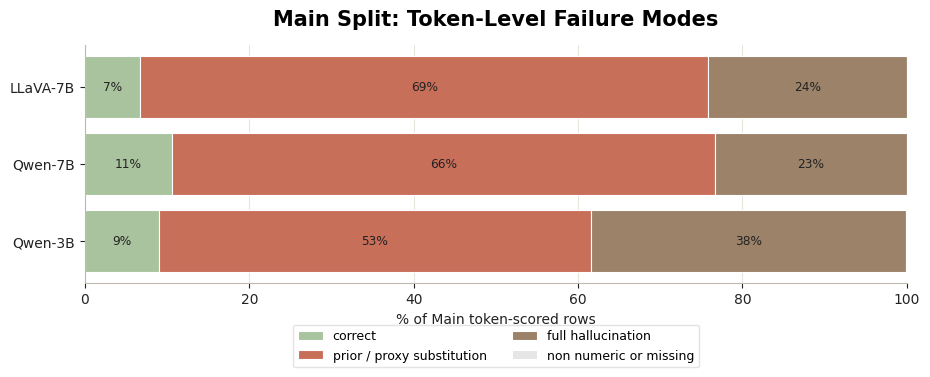

In [20]:
def plot_failure_mode_stacked_bars(token_all):
    main = token_all[token_all["split"].eq("Main")].copy()
    model_outcome = (
        main
        .groupby(["model", "outcome"], observed=True)
        .size()
        .reset_index(name="n")
    )
    model_outcome["total"] = model_outcome.groupby("model", observed=True)["n"].transform("sum")
    model_outcome["pct"] = 100 * model_outcome["n"] / model_outcome["total"]
    model_outcome.to_csv(TAB_DIR / "figure6_main_failure_mode_distribution_by_model.csv", index=False)

    pivot = (
        model_outcome
        .pivot_table(index="model", columns="outcome", values="pct", fill_value=0, observed=True)
        .reindex(index=MODEL_ORDER, columns=OUTCOME_ORDER, fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(9.4, 4.2))
    left = np.zeros(len(pivot))

    for outcome in OUTCOME_ORDER:
        vals = pivot[outcome].to_numpy()
        bars = ax.barh(
            pivot.index.astype(str),
            vals,
            left=left,
            color=OUTCOME_COLORS[outcome],
            edgecolor="white",
            linewidth=0.8,
            label=outcome,
        )
        for bar, val, lft in zip(bars, vals, left):
            if val >= 6:
                ax.text(lft + val / 2, bar.get_y() + bar.get_height() / 2, f"{val:.0f}%", ha="center", va="center", fontsize=8.7, color="#222222")
        left += vals

    ax.set_xlim(0, 100)
    ax.set_xlabel("% of Main token-scored rows")
    ax.set_title("Main Split: Token-Level Failure Modes", fontsize=15, weight="bold", pad=14)
    ax.legend(ncol=2, frameon=True, facecolor="white", edgecolor="#DDDDDD", loc="lower center", bbox_to_anchor=(0.5, -0.38), fontsize=9)
    clean_axes(ax, grid_axis="x")
    save_figure("fig6_main_failure_mode_stacked_bars")
    plt.show()

plot_failure_mode_stacked_bars(token_all)

## 10. Appendix outputs: PMI robustness, heatmaps, error magnitude

In [21]:
# 10. Appendix outputs: PMI robustness, heatmaps, error magnitude

## ---------- PMI robustness table ----------


PMI robustness by split and model


,split,model,n,raw_gt_pref_pct,pmi_gt_pref_pct,pmi_minus_raw_pct,sign_agreement_pct,mean_raw_margin,mean_pmi_margin
0,Main,Qwen-3B,1990,19.45,27.29,7.84,89.10,-1.31,-1.25
1,Main,Qwen-7B,1992,15.26,15.16,-0.10,96.59,-3.65,-3.65
2,Main,LLaVA-7B,1992,16.92,19.03,2.11,91.57,-2.78,-2.57
3,Original,Qwen-3B,162,72.84,79.01,6.17,88.89,2.38,2.44
4,Original,Qwen-7B,163,90.18,90.18,0.00,97.55,5.05,5.27
5,Original,LLaVA-7B,163,84.66,82.21,-2.45,94.48,3.76,4.05


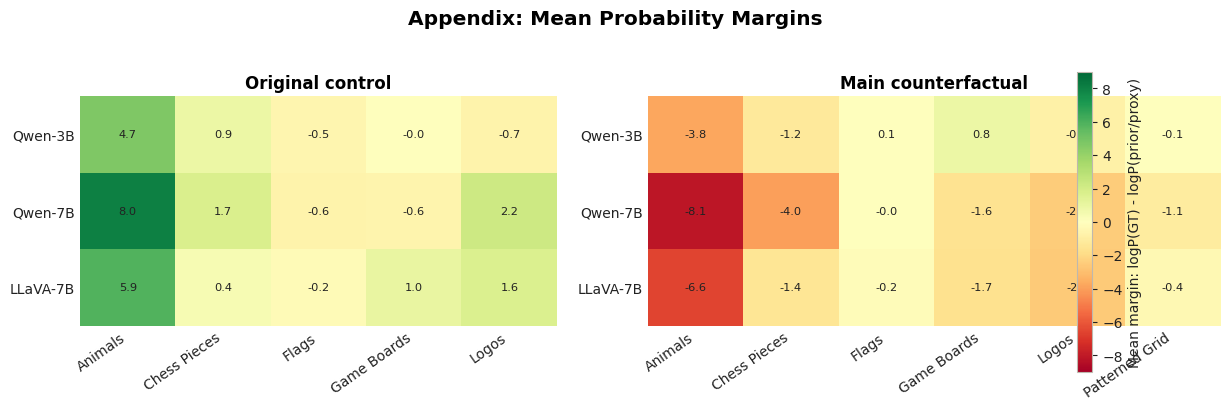

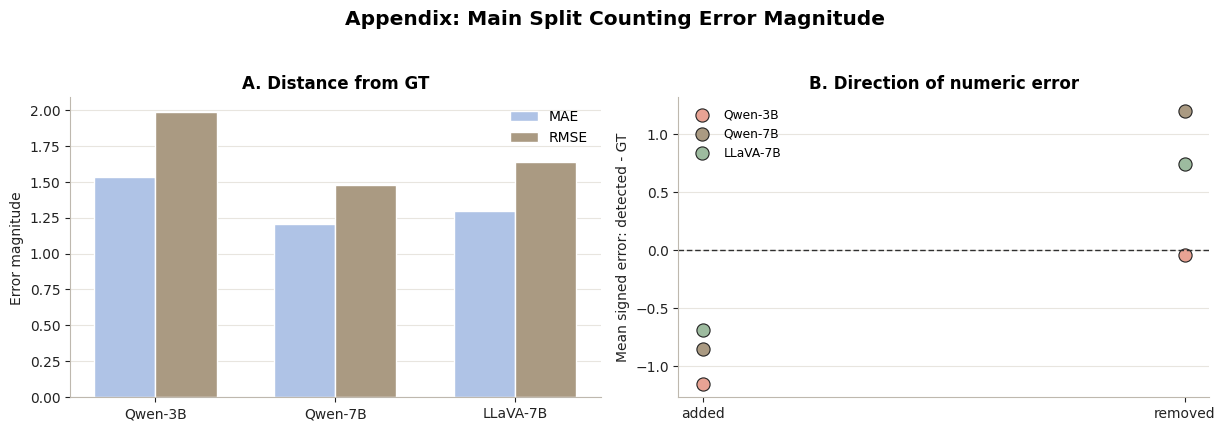


Saved outputs
  Figures: /Users/ayatkhudoir/Desktop/results/BiasInLVLMs-main 3/main_probability_analysis_outputs_clean/figures
  Tables:  /Users/ayatkhudoir/Desktop/results/BiasInLVLMs-main 3/main_probability_analysis_outputs_clean/tables


In [22]:
# ---------- PMI robustness table ----------
pmi_robustness = (
    sequence_all[sequence_all["pmi_margin"].notna()]
    .assign(
        raw_prefers_gt=lambda d: d["sequence_margin"] > 0,
        pmi_prefers_gt=lambda d: d["pmi_margin"] > 0,
        sign_agreement=lambda d: np.sign(d["sequence_margin"]) == np.sign(d["pmi_margin"]),
    )
    .groupby(["split", "model"], observed=True)
    .agg(
        n=("sequence_margin", "size"),
        raw_gt_pref_pct=("raw_prefers_gt", pct_mean),
        pmi_gt_pref_pct=("pmi_prefers_gt", pct_mean),
        pmi_minus_raw_pct=("pmi_prefers_gt", pct_mean),
        sign_agreement_pct=("sign_agreement", pct_mean),
        mean_raw_margin=("sequence_margin", "mean"),
        mean_pmi_margin=("pmi_margin", "mean"),
    )
    .reset_index()
)
# Replace temporary pmi_minus_raw with true difference.
pmi_robustness["pmi_minus_raw_pct"] = pmi_robustness["pmi_gt_pref_pct"] - pmi_robustness["raw_gt_pref_pct"]
pmi_robustness.to_csv(TAB_DIR / "appendix_pmi_robustness_by_split_model.csv", index=False)

pmi_domain_robustness = (
    sequence_all[sequence_all["pmi_margin"].notna()]
    .assign(
        raw_prefers_gt=lambda d: d["sequence_margin"] > 0,
        pmi_prefers_gt=lambda d: d["pmi_margin"] > 0,
        sign_agreement=lambda d: np.sign(d["sequence_margin"]) == np.sign(d["pmi_margin"]),
    )
    .groupby(["split", "model", "topic"], observed=True)
    .agg(
        n=("sequence_margin", "size"),
        raw_gt_pref_pct=("raw_prefers_gt", pct_mean),
        pmi_gt_pref_pct=("pmi_prefers_gt", pct_mean),
        sign_agreement_pct=("sign_agreement", pct_mean),
        mean_raw_margin=("sequence_margin", "mean"),
        mean_pmi_margin=("pmi_margin", "mean"),
    )
    .reset_index()
)
pmi_domain_robustness["pmi_minus_raw_pct"] = pmi_domain_robustness["pmi_gt_pref_pct"] - pmi_domain_robustness["raw_gt_pref_pct"]
pmi_domain_robustness.to_csv(TAB_DIR / "appendix_pmi_robustness_by_split_model_topic.csv", index=False)

print("\nPMI robustness by split and model")
display(pmi_robustness.round(2))

# ---------- Appendix heatmap: Original vs Main mean margins ----------
def plot_margin_heatmaps(sequence_all):
    main_heat = (
        sequence_all[sequence_all["split"].eq("Main")]
        .pivot_table(index="model", columns="topic", values="sequence_margin", aggfunc="mean", observed=True)
        .reindex(index=MODEL_ORDER, columns=TOPIC_ORDER)
    )
    orig_heat = (
        sequence_all[sequence_all["split"].eq("Original")]
        .pivot_table(index="model", columns="topic", values="sequence_margin", aggfunc="mean", observed=True)
        .reindex(index=MODEL_ORDER, columns=ORIGINAL_TOPIC_ORDER)
    )
    main_heat.to_csv(TAB_DIR / "appendix_main_mean_margin_heatmap_values.csv")
    orig_heat.to_csv(TAB_DIR / "appendix_original_mean_margin_heatmap_values.csv")

    values = pd.concat([main_heat.stack(), orig_heat.stack()]).dropna()
    vmax = np.ceil(np.nanmax(np.abs(values))) if len(values) else 1

    fig, axes = plt.subplots(1, 2, figsize=(12.4, 3.9), gridspec_kw={"width_ratios": [1.0, 1.2]})
    cmap = "RdYlGn"

    for ax, mat, title in [
        (axes[0], orig_heat, "Original control"),
        (axes[1], main_heat, "Main counterfactual"),
    ]:
        im = ax.imshow(mat.to_numpy(dtype=float), cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")
        ax.set_title(title, weight="bold")
        ax.set_xticks(np.arange(mat.shape[1]))
        ax.set_xticklabels(mat.columns.astype(str), rotation=35, ha="right")
        ax.set_yticks(np.arange(mat.shape[0]))
        ax.set_yticklabels(mat.index.astype(str))
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat.iloc[i, j]
                if pd.notna(val):
                    ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8.2, color="#222222")
        ax.tick_params(length=0)
        for spine in ax.spines.values():
            spine.set_visible(False)

    cbar = fig.colorbar(im, ax=axes, fraction=0.035, pad=0.03)
    cbar.set_label("Mean margin: logP(GT) - logP(prior/proxy)")
    fig.suptitle("Appendix: Mean Probability Margins", fontsize=14.5, weight="bold", y=1.04)
    save_figure("appendix_mean_margin_heatmaps_original_main")
    plt.show()

plot_margin_heatmaps(sequence_all)

# ---------- Appendix error magnitude ----------
main_errors = token_all[token_all["split"].eq("Main")].dropna(subset=["detected_digit", "gt_value"]).copy()
error_model = (
    main_errors
    .groupby("model", observed=True)
    .agg(
        n=("signed_error", "size"),
        mean_signed_error=("signed_error", "mean"),
        MAE=("abs_error", "mean"),
        RMSE=("squared_error", rmse_from_squared),
    )
    .reset_index()
)
error_direction = (
    main_errors
    .groupby(["model", "direction"], observed=True)
    .agg(
        n=("signed_error", "size"),
        mean_signed_error=("signed_error", "mean"),
        MAE=("abs_error", "mean"),
        RMSE=("squared_error", rmse_from_squared),
    )
    .reset_index()
)
error_model.to_csv(TAB_DIR / "appendix_error_magnitude_by_model.csv", index=False)
error_direction.to_csv(TAB_DIR / "appendix_error_magnitude_by_model_direction.csv", index=False)


def plot_error_magnitude(error_model, error_direction):
    fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.1))
    x = np.arange(len(MODEL_ORDER))
    w = 0.34
    em = error_model.set_index("model").reindex(MODEL_ORDER)

    axes[0].bar(x - w / 2, em["MAE"], width=w, color=REPORT_COLORS["blue"], edgecolor="white", label="MAE")
    axes[0].bar(x + w / 2, em["RMSE"], width=w, color=REPORT_COLORS["taupe"], edgecolor="white", label="RMSE")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(MODEL_ORDER)
    axes[0].set_ylabel("Error magnitude")
    axes[0].set_title("A. Distance from GT", weight="bold")
    axes[0].legend(frameon=False)
    clean_axes(axes[0])

    for model in MODEL_ORDER:
        sub = error_direction[error_direction["model"].astype(str).eq(model)]
        axes[1].scatter(sub["direction"], sub["mean_signed_error"], s=90, color=MODEL_COLORS[model], edgecolor="#222222", linewidth=0.8, label=model)
    axes[1].axhline(0, color=REPORT_COLORS["dark"], linestyle=(0, (4, 2)), linewidth=1)
    axes[1].set_ylabel("Mean signed error: detected - GT")
    axes[1].set_title("B. Direction of numeric error", weight="bold")
    axes[1].legend(frameon=False, fontsize=8.8)
    clean_axes(axes[1])

    fig.suptitle("Appendix: Main Split Counting Error Magnitude", fontsize=14.5, weight="bold", y=1.04)
    save_figure("appendix_counting_error_magnitude_direction")
    plt.show()

plot_error_magnitude(error_model, error_direction)

# ---------- Appendix domain-level failure mode distribution ----------
domain_outcome = (
    token_all[token_all["split"].eq("Main")]
    .groupby(["model", "topic", "outcome"], observed=True)
    .size()
    .reset_index(name="n")
)
domain_outcome["total"] = domain_outcome.groupby(["model", "topic"], observed=True)["n"].transform("sum")
domain_outcome["pct"] = 100 * domain_outcome["n"] / domain_outcome["total"]
domain_outcome.to_csv(TAB_DIR / "appendix_domain_failure_mode_distribution.csv", index=False)

print("\nSaved outputs")
print(f"  Figures: {FIG_DIR.resolve()}")
print(f"  Tables:  {TAB_DIR.resolve()}")